# Disaster Tweet Classification

Goal:
Classify whether a tweet refers to a real disaster or not.

Approach:
Compared multiple NLP techniques including BoW, TF-IDF, Word2Vec, and GloVe.

In [79]:
import pandas as pd
import numpy as np

df = pd.read_csv("train.csv")
df

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


In [80]:
df1 = pd.read_csv("train.csv")
df2 = pd.read_csv("disaster_tweets_dataset.csv")

# keep only required columns (important!)
df1 = df1[["text", "target"]]
df2 = df2[["text", "target"]]

# merge (append rows)
df = pd.concat([df1, df2], ignore_index=True)

print(df.shape)

(7723, 2)


In [81]:

X = df[['text']]
y = df['target']

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [83]:

    chat_words = {'a3': 'anytime, anywhere, anyplace',
 'adih': 'another day in hell',
 'afk': 'away from keyboard',
 'afaik': 'as far as i know',
 'asap': 'as soon as possible',
 'asl': 'age, sex, location',
 'atk': 'at the keyboard',
 'atm': 'at the moment',
 'bae': 'before anyone else',
 'bak': 'back at keyboard',
 'bbl': 'be back later',
 'bbs': 'be back soon',
 'bfn': 'bye for now',
 'b4n': 'bye for now',
 'brb': 'be right back',
 'bruh': 'bro',
 'brt': 'be right there',
 'bsaaw': 'big smile and a wink',
 'btw': 'by the way',
 'bwl': 'bursting with laughter',
 'csl': 'can’t stop laughing',
 'cu': 'see you',
 'cul8r': 'see you later',
 'cya': 'see you',
 'dm': 'direct message',
 'faq': 'frequently asked questions',
 'fc': 'fingers crossed',
 'fimh': 'forever in my heart',
 'fomo': 'fear of missing out',
 'fr': 'for real',
 'fwiw': "for what it's worth",
 'fyp': 'for you page',
 'fyi': 'for your information',
 'g9': 'genius',
 'gal': 'get a life',
 'gg': 'good game',
 'gmta': 'great minds think alike',
 'gn': 'good night',
 'goat': 'greatest of all time',
 'gr8': 'great!',
 'hbd': 'happy birthday',
 'ic': 'i see',
 'icq': 'i seek you',
 'idc': 'i don’t care',
 'idk': "i don't know",
 'ifyp': 'i feel your pain',
 'ilu': 'i love you',
 'ily': 'i love you',
 'imho': 'in my honest/humble opinion',
 'imu': 'i miss you',
 'imo': 'in my opinion',
 'iow': 'in other words',
 'irl': 'in real life',
 'iykyk': 'if you know, you know',
 'jk': 'just kidding',
 'kiss': 'keep it simple, stupid',
 'l': 'loss',
 'l8r': 'later',
 'ldr': 'long distance relationship',
 'lmk': 'let me know',
 'lmao': 'laughing my a** off',
 'lol': 'laughing out loud',
 'ltns': 'long time no see',
 'm8': 'mate',
 'mfw': 'my face when',
 'mid': 'mediocre',
 'mrw': 'my reaction when',
 'mte': 'my thoughts exactly',
 'nvm': 'never mind',
 'nrn': 'no reply necessary',
 'npc': 'non-player character',
 'oic': 'oh i see',
 'op': 'overpowered',
 'pita': 'pain in the a**',
 'pov': 'point of view',
 'prt': 'party',
 'prw': 'parents are watching',
 'rofl': 'rolling on the floor laughing',
 'roflol': 'rolling on the floor laughing out loud',
 'rotflmao': 'rolling on the floor laughing my a** off',
 'rn': 'right now',
 'sk8': 'skate',
 'stats': 'your sex and age',
 'sus': 'suspicious',
 'tbh': 'to be honest',
 'tfw': 'that feeling when',
 'thx': 'thank you',
 'time': 'tears in my eyes',
 'tldr': 'too long, didn’t read',
 'tntl': 'trying not to laugh',
 'ttfn': 'ta-ta for now!',
 'ttyl': 'talk to you later',
 'u': 'you',
 'u2': 'you too',
 'u4e': 'yours for ever',
 'w': 'win',
 'w8': 'wait...',
 'wb': 'welcome back',
 'wtf': 'what the f**k',
 'wtg': 'way to go!',
 'wuf': 'where are you from?',
 'wyd': 'what you doing?',
 'wywh': 'wish you were here',
 'zzz': 'sleeping, bored, tired'}

In [84]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))



def clean_text(text):
    
    # 1. lowercase
    text = text.lower()
    
    # 2. remove html
    text = re.sub(r'<.*?>', '', text)
    
    # 3. remove urls
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # 4. replace chat words
    words = text.split()
    words = [chat_words[word] if word in chat_words else word for word in words]
    text = " ".join(words)
    
    # 5. remove punctuation
    #text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 6. tokenize
    words = text.split()
    
    # 7. remove stopwords and stem
    #words = [ps.stem(word) for word in words if word not in stop_words]
    
    # 8. join back
    text = " ".join(words)
    
    return text

In [85]:
X_train['text']=X_train['text'].apply(clean_text)
X_test['text']=X_test['text'].apply(clean_text)

In [86]:
results=[]

### BOW

In [87]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=10000)
bow_train=cv.fit_transform(X_train['text'])
bow_test=cv.transform(X_test['text'])

In [88]:
from sklearn.linear_model import LogisticRegression
bow_model=LogisticRegression()

bow_model.fit(bow_train,y_train)
y_pred=bow_model.predict(bow_test)
y_pred

array([1, 0, 1, ..., 1, 0, 0], dtype=int64)

In [89]:
def predict(tweet):
    cleaned = clean_text(tweet)
    vector = cv.transform([cleaned])
    return bow_model.predict(vector)[0]


print(predict("his instagram feed was flooded with cat images"))
print(predict("all the buildings in that area were flooded"))

0
1


In [90]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.8097087378640777
F1: 0.7688679245283019


In [91]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.8096026490066225
Recall: 0.7320359281437125


In [92]:
results.append((
    "BoW",
    accuracy_score(y_test, y_pred),
    f1_score(y_test, y_pred)
))

In [93]:
results

[('BoW', 0.8097087378640777, 0.7688679245283019)]

### tfidf

In [94]:
X_train_clean_tfidf = X_train['text']
X_test_clean_tfidf = X_test['text']

In [95]:
print(X_train_clean_tfidf[:10])

4758                        @benji_devos thanks thanks :3
3584     @_asianshawtyy ?????????? i'm sorry. but i'm out
460     delhi government to provide free treatment to ...
507     i attacked robot-lvl 19 and i've earned a tota...
64      #nowplaying: rene ablaze &amp; ian buff - magn...
167     statistically i'm at more of risk of getting k...
11      haha south tampa is getting flooded hah- wait ...
2645                         it sure made an impact on me
1357    strikers in phalaborwa striking over the chine...
7368    nema ekiti distributed relief materials to aff...
Name: text, dtype: object


In [96]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train_clean_tfidf)
X_test_tfidf = tfidf.transform(X_test_clean_tfidf)

tfidf_model = LogisticRegression(max_iter=1000)
tfidf_model.fit(X_train_tfidf, y_train)

y_pred = tfidf_model.predict(X_test_tfidf)

results.append((
    "TF-IDF",
    accuracy_score(y_test, y_pred),
    f1_score(y_test, y_pred)
))

In [97]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.8248686514886164
Recall: 0.7050898203592815


In [98]:
def predict(tweet):
    cleaned = clean_text(tweet)
    vector = tfidf.transform([cleaned])
    return tfidf_model.predict(vector)[0]


print(predict("his instagram feed was flooded with cat images"))
print(predict("all the buildings in that area were flooded"))

0
1


In [99]:
results

[('BoW', 0.8097087378640777, 0.7688679245283019),
 ('TF-IDF', 0.8077669902912621, 0.7602905569007264)]

### gloVe

In [100]:
def clean_text_glove(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    
    words = text.split()
    words = [chat_words[word] if word in chat_words else word for word in words]
    
    text = " ".join(words)
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return words   # 👈 IMPORTANT (list, not string)

In [101]:
X_train_tokens=X_train['text'].apply(clean_text_glove)
X_test_tokens=X_test['text'].apply(clean_text_glove)

In [102]:
# collect all words used in your dataset
vocab = set()

for tokens in X_train_tokens:
    vocab.update(tokens)

for tokens in X_test_tokens:
    vocab.update(tokens)

print("Total unique words:", len(vocab))

Total unique words: 17973


In [103]:
embeddings = {}

with open("glove.6B.300d.txt", encoding="utf8") as f:
    
    for line in f:
        
        values = line.split()
        
        word = values[0]
        
        vector = np.asarray(values[1:], dtype="float32")
        
        embeddings[word] = vector

In [104]:
reduced_embeddings = {}

for word in vocab:
    if word in embeddings:
        reduced_embeddings[word] = embeddings[word]

print("Reduced embeddings size:", len(reduced_embeddings))

Reduced embeddings size: 12221


In [105]:
print("Loaded words:", len(embeddings))

Loaded words: 400000


In [106]:
def get_glove_vector(tokens):

    vectors = []

    for word in tokens:

        if word in embeddings:
            vectors.append(embeddings[word])

    if len(vectors) == 0:
        return np.zeros(300)

    return np.mean(vectors, axis=0)

In [107]:
X_train_vectors = np.array([
    get_glove_vector(tokens) for tokens in X_train_tokens
])

X_test_vectors = np.array([
    get_glove_vector(tokens) for tokens in X_test_tokens
])

In [108]:
X_train_vectors.shape

(6178, 300)

In [109]:
from sklearn.svm import LinearSVC

glove_model = LinearSVC()

glove_model.fit(X_train_vectors, y_train)
glove_model = LinearSVC()
glove_model.fit(X_train_vectors, y_train)

y_pred = glove_model.predict(X_test_vectors)

results.append((
    "GloVe",
    accuracy_score(y_test, y_pred),
    f1_score(y_test, y_pred)
))

In [110]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.7801302931596091
Recall: 0.7170658682634731


In [111]:
def predict(tweet):
    cleaned = clean_text_glove(tweet)
    vector = get_glove_vector(cleaned)             # step 2: convert to vector (300d)
    
    return glove_model.predict([vector])[0] 


print(predict("his instagram feed was flooded with cat images"))
print(predict("all the buildings in that area were flooded"))

0
1


In [112]:
results

[('BoW', 0.8097087378640777, 0.7688679245283019),
 ('TF-IDF', 0.8077669902912621, 0.7602905569007264),
 ('GloVe', 0.7902912621359224, 0.7472698907956318)]

### tfidf weighted GloVe

In [113]:

#tfidf = TfidfVectorizer()
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),   # BIG BOOST
    min_df=2,
    max_df=0.9,
    sublinear_tf=True    # 🔥 important
)
tfidf.fit(X_train_clean_tfidf)

tfidf_vocab = tfidf.vocabulary_

In [114]:
def get_weighted_glove_vector(tokens, text):

    vector = np.zeros(300)
    weight_sum = 0

    #tfidf_vector = tfidf.transform([text]).toarray()[0]
    tfidf_vector = tfidf.transform([text])

    for word in tokens:
        if word in embeddings and word in tfidf.vocabulary_:
            idx = tfidf.vocabulary_[word]
            weight = tfidf_vector[0,idx]

            if weight > 0:
                vector += embeddings[word] * weight
                weight_sum += weight

    if weight_sum != 0:
        vector /= weight_sum

    return vector

In [115]:
from tqdm import tqdm


X_train_vectors = np.array([
    get_weighted_glove_vector(tokens, text)
    for tokens, text in tqdm(zip(X_train_tokens, X_train_clean_tfidf), total=len(X_train_tokens))
])

X_test_vectors = np.array([
    get_weighted_glove_vector(tokens, text)
    for tokens, text in tqdm(zip(X_test_tokens, X_test_clean_tfidf), total=len(X_test_tokens))
])

100%|█████████████████████████████████████████████████████████████████████████████| 1545/1545 [00:02<00:00, 691.31it/s]


In [116]:
from sklearn.svm import LinearSVC

weighted_glove_model = LinearSVC(C=1.5)

weighted_glove_model.fit(X_train_vectors, y_train)

LinearSVC(C=1.5)

In [117]:
y_pred = weighted_glove_model.predict(X_test_vectors)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))

Accuracy: 0.7695792880258899
F1 score: 0.7269938650306749


In [118]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.7452830188679245
Recall: 0.7095808383233533


In [119]:
results.append((
    "TF-IDF + GloVe",
    accuracy_score(y_test, y_pred),
    f1_score(y_test, y_pred)
))

In [120]:
def predict(tweet):
    tokens = clean_text_glove(tweet)                     # tokens
    text = " ".join(tokens)                              # convert to string for TF-IDF
    
    vector = get_weighted_glove_vector(tokens, text)     # SAME as training
    
    return weighted_glove_model.predict([vector])[0]

In [121]:
print(predict("his instagram feed was flooded with cat images"))
print(predict("all the buildings in that area were flooded"))

0
1


In [122]:
results

[('BoW', 0.8097087378640777, 0.7688679245283019),
 ('TF-IDF', 0.8077669902912621, 0.7602905569007264),
 ('GloVe', 0.7902912621359224, 0.7472698907956318),
 ('TF-IDF + GloVe', 0.7695792880258899, 0.7269938650306749)]

In [123]:
results

[('BoW', 0.8097087378640777, 0.7688679245283019),
 ('TF-IDF', 0.8077669902912621, 0.7602905569007264),
 ('GloVe', 0.7902912621359224, 0.7472698907956318),
 ('TF-IDF + GloVe', 0.7695792880258899, 0.7269938650306749)]

In [124]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1"])

results_df.sort_values(by="F1", ascending=False)

,Model,Accuracy,F1
0,BoW,0.809709,0.768868
1,TF-IDF,0.807767,0.760291
2,GloVe,0.790291,0.747270
3,TF-IDF + GloVe,0.769579,0.726994


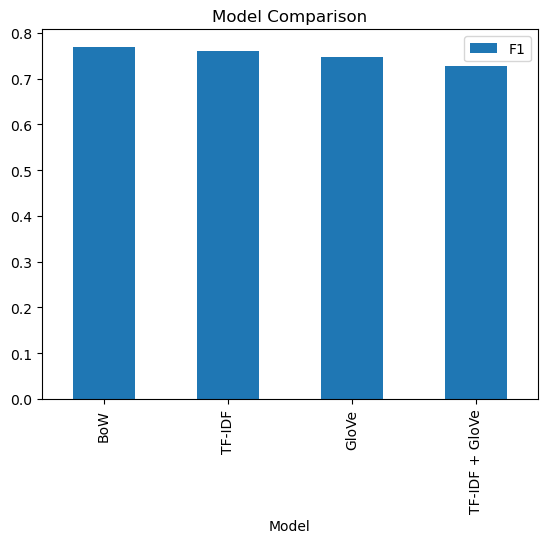

In [125]:
import matplotlib.pyplot as plt

results_df.plot(x="Model", y="F1", kind="bar")
plt.title("Model Comparison")
plt.show()

#### Conclusion:

- TF-IDF and BoW performed best due to keyword-heavy dataset.
- Embedding-based methods like GloVe captured semantics but lost keyword importance.
- Simpler models outperformed complex ones for this task.

In [127]:
import pickle

# vectorizers
pickle.dump(tfidf, open("tfidf.pkl", "wb"))
pickle.dump(cv, open("bow.pkl", "wb"))

# models
pickle.dump(tfidf_model, open("tfidf_model.pkl", "wb"))
pickle.dump(bow_model, open("bow_model.pkl", "wb"))
pickle.dump(glove_model, open("glove_model.pkl", "wb"))
pickle.dump(weighted_glove_model, open("weighted_glove_model.pkl", "wb"))

# embeddings (optional but better separate)
pickle.dump(embeddings, open("glove_embeddings.pkl", "wb"))
pickle.dump(reduced_embeddings, open("glove_reduced.pkl", "wb"))

In [126]:
print(len(embeddings))          # ~400000
print(len(reduced_embeddings))  # ~10000–20000

400000
12221
